Generation 0: Best Fitness = 107
Generation 1: Best Fitness = 107
Generation 2: Best Fitness = 93
Generation 3: Best Fitness = 87
Generation 4: Best Fitness = 85
Generation 5: Best Fitness = 85
Generation 6: Best Fitness = 85
Generation 7: Best Fitness = 75
Generation 8: Best Fitness = 75
Generation 9: Best Fitness = 75
Generation 10: Best Fitness = 69
Generation 11: Best Fitness = 69
Generation 12: Best Fitness = 69
Generation 13: Best Fitness = 67
Generation 14: Best Fitness = 67
Generation 15: Best Fitness = 67
Generation 16: Best Fitness = 67
Generation 17: Best Fitness = 65
Generation 18: Best Fitness = 65
Generation 19: Best Fitness = 62
Generation 20: Best Fitness = 62
Generation 21: Best Fitness = 62
Generation 22: Best Fitness = 62
Generation 23: Best Fitness = 62
Generation 24: Best Fitness = 62
Generation 25: Best Fitness = 57
Generation 26: Best Fitness = 57
Generation 27: Best Fitness = 57
Generation 28: Best Fitness = 57
Generation 29: Best Fitness = 57
Generation 30: Bes

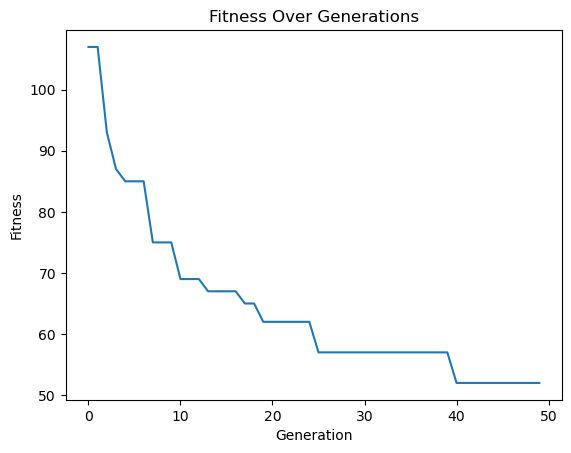

Best Solution: {'hap_assignments': [1, 1, 0, 1, 0, 0], 'schedule': [[0, 3], [0, 3], [1, 3], [5, 4], [5, 4]]}


In [9]:
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

# Read the dataset
df = pd.read_csv('Sample_Game_1_RawEventsData-Copy1.csv')

# Parameters
num_teams = 6
num_rounds = 5
venue_capacity = 3
population_size = 20
generations = 50
mutation_rate = 0.1

def calculate_distance_matrix(num_teams):
    """Step 1: Calculate Distance Matrix"""
    distance_matrix = np.random.randint(1, 50, size=(num_teams, num_teams))
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix

def initialize_population():
    """Step 2: Initialization"""
    population = []
    for _ in range(population_size):
        chromosome = {
            "hap_assignments": np.random.choice(len(HAPs), num_teams).tolist(),
            "schedule": [
                random.sample(range(num_teams), 2) for _ in range(num_rounds)
            ],
        }
        population.append(chromosome)
    return population

def evaluate_fitness(chromosome, distance_matrix):
    """Step 3: Fitness Evaluation"""
    hap_assignments = chromosome["hap_assignments"]
    schedule = chromosome["schedule"]

    # Calculate capacity violations
    capacity_violations = 0
    for round_idx in range(num_rounds):
        home_teams = [team for team, hap in enumerate(hap_assignments)
                      if HAPs[hap][round_idx] == "H"]
        if len(home_teams) > venue_capacity:
            capacity_violations += len(home_teams) - venue_capacity

    # Calculate travel distance
    travel_distance = 0
    for match in schedule:
        team_a, team_b = match
        travel_distance += distance_matrix[team_a, team_b]

    # Fitness is a combination of capacity violations and travel distance
    return capacity_violations * 100 + travel_distance

def selection(population, distance_matrix):
    """Step 4: Selection"""
    population.sort(key=lambda x: evaluate_fitness(x, distance_matrix))
    return population[:population_size // 2]

def crossover(parent1, parent2):
    """Step 5: Crossover"""
    crossover_point = random.randint(1, num_teams - 1)
    child1 = {
        "hap_assignments": parent1["hap_assignments"][:crossover_point] + 
        parent2["hap_assignments"][crossover_point:],
        "schedule": parent1["schedule"][:crossover_point] +
        parent2["schedule"][crossover_point:],
    }
    child2 = {
        "hap_assignments": parent2["hap_assignments"][:crossover_point] + 
        parent1["hap_assignments"][crossover_point:],
        "schedule": parent2["schedule"][:crossover_point] + 
        parent1["schedule"][crossover_point:],
    }
    return child1, child2

def mutate(chromosome):
    """Step 6: Mutation"""
    if random.random() < mutation_rate:
        team_idx = random.randint(0, num_teams - 1)
        chromosome["hap_assignments"][team_idx] = random.randint(0, len(HAPs) - 1)
    if random.random() < mutation_rate:
        round_idx = random.randint(0, num_rounds - 1)
        chromosome["schedule"][round_idx] = random.sample(range(num_teams), 2)
    return chromosome

def replace_population(population, new_population):
    """Step 7: Replacement"""
    return new_population

def genetic_algorithm():
    """Step 8: Iteration and Step 9: Termination"""
    distance_matrix = calculate_distance_matrix(num_teams)
    population = initialize_population()
    best_solution = None
    best_fitness = float("inf")
    fitness_history = []

    for generation in range(generations):
        # Evaluate and select the top solutions
        selected_population = selection(population, distance_matrix)

        # Generate new offspring
        new_population = []
        while len(new_population) < population_size:
            parent1, parent2 = random.sample(selected_population, 2)
            child1, child2 = crossover(parent1, parent2)
            new_population.append(mutate(child1))
            new_population.append(mutate(child2))

        # Replace the population with new offspring
        population = replace_population(population, new_population)

        # Track the best solution
        for chromosome in population:
            fitness = evaluate_fitness(chromosome, distance_matrix)
            if fitness < best_fitness:
                best_fitness = fitness
                best_solution = chromosome

        fitness_history.append(best_fitness)
        print(f"Generation {generation}: Best Fitness = {best_fitness}")

    return best_solution, fitness_history

def plot_results(fitness_history):
    """Step 10: Show Result and Plot"""
    plt.plot(fitness_history)
    plt.title("Fitness Over Generations")
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.show()

# Home-Away Patterns (HAPs)
HAPs = [
    ["H", "A", "H", "A", "H"],
    ["A", "H", "A", "H", "A"],
]

# Run the Genetic Algorithm
best_solution, fitness_history = genetic_algorithm()
plot_results(fitness_history)
print("Best Solution:", best_solution)
